# Implementation of Machine Learning Methodology on US Accidents Dataset (2016–2023)
# Author: Zayyam Waseem
# Date: 2026-03-30

## Introduction

This notebook implements the machine learning methodology on the US Accidents dataset (2016–2023). The objective is to analyze accident patterns and predict accident severity using various machine learning models.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('/kaggle/input/datasets/sobhanmoosavi/us-accidents/US_Accidents_March23.csv')

print("Dataset loaded")
df.head()


Dataset loaded


,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Night
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Day
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,NaN,NaN,0.01,...,False,False,False,False,True,False,Night,Night,Day,Day
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Day,Day,Day
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,NaN,NaN,0.01,...,False,False,False,False,True,False,Day,Day,Day,Day


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier


## Data Preprocessing and Feature Engineering

In this step, relevant features were selected from the dataset. The time column was converted into datetime format, and new features such as hour, day of week, month, and weekend indicator were extracted.

Missing values in numerical features were handled using median imputation, while categorical values were filled with default labels. A binary target variable was created from the severity column to enable classification.


In [3]:
# Creating a clean modeling dataframe

work_df = df[[
    'Severity',
    'Start_Time',
    'Temperature(F)',
    'Humidity(%)',
    'Visibility(mi)',
    'Wind_Speed(mph)',
    'Weather_Condition',
    'Sunrise_Sunset'
]].copy()

# Converting time column
work_df['Start_Time'] = pd.to_datetime(work_df['Start_Time'], errors='coerce')
work_df = work_df.dropna(subset=['Severity', 'Start_Time'])

# Feature engineering from time
work_df['Hour'] = work_df['Start_Time'].dt.hour
work_df['DayOfWeek'] = work_df['Start_Time'].dt.day_name()
work_df['Month'] = work_df['Start_Time'].dt.month
work_df['Is_Weekend'] = work_df['Start_Time'].dt.dayofweek.isin([5, 6]).astype(int)

# Binary target for accident severity
work_df['Target'] = (work_df['Severity'] >= 3).astype(int)

# Handling missing categorical values
work_df['Weather_Condition'] = work_df['Weather_Condition'].fillna('Unknown')
work_df['Sunrise_Sunset'] = work_df['Sunrise_Sunset'].fillna('Unknown')

# Keep only top weather categories and group the rest as Other
top_weather = work_df['Weather_Condition'].value_counts().head(10).index
work_df['Weather_Condition'] = work_df['Weather_Condition'].where(
    work_df['Weather_Condition'].isin(top_weather),
    'Other'
)

# Filling missing numerical values with median
num_cols = ['Temperature(F)', 'Humidity(%)', 'Visibility(mi)', 'Wind_Speed(mph)']
for col in num_cols:
    work_df[col] = work_df[col].fillna(work_df[col].median())

work_df.head()


,Severity,Start_Time,Temperature(F),Humidity(%),Visibility(mi),Wind_Speed(mph),Weather_Condition,Sunrise_Sunset,Hour,DayOfWeek,Month,Is_Weekend,Target
0,3,2016-02-08 05:46:00,36.9,91.0,10.0,7.0,Light Rain,Night,5,Monday,2,0,1
1,2,2016-02-08 06:07:59,37.9,100.0,10.0,7.0,Light Rain,Night,6,Monday,2,0,0
2,2,2016-02-08 06:49:27,36.0,100.0,10.0,3.5,Overcast,Night,6,Monday,2,0,0
3,3,2016-02-08 07:23:34,35.1,96.0,9.0,4.6,Mostly Cloudy,Night,7,Monday,2,0,1
4,2,2016-02-08 07:39:07,36.0,89.0,6.0,3.5,Mostly Cloudy,Day,7,Monday,2,0,0


In this step, raw accident data was converted into a structured modeling table. Time-based features such as hour, day of week, month, and weekend flag were extracted from the timestamp. A binary target variable was created from accident severity to support classification. Missing numerical values were filled using the median, while missing categorical values were replaced with a default label. Rare weather categories were grouped into an “Other” class to reduce noise.

## Exploratory Data Analysis (EDA)

EDA was performed to understand the structure and relationships within the dataset. Visualizations and correlation analysis were used to identify patterns and dependencies between features.


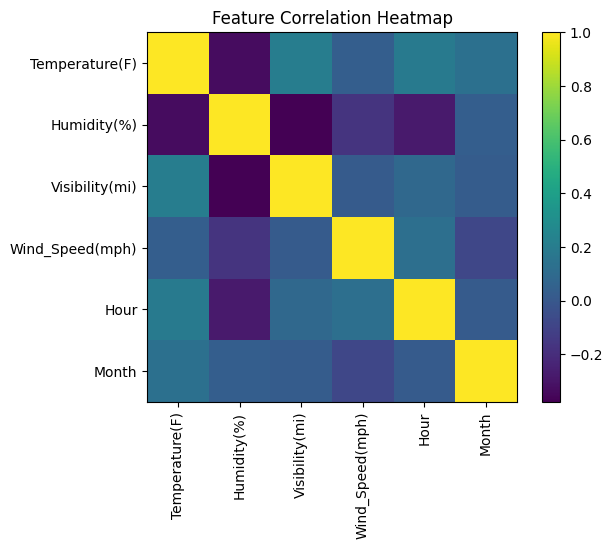

In [4]:
# Correlation heatmap (numerical features)
corr = work_df[['Temperature(F)', 'Humidity(%)', 'Visibility(mi)', 'Wind_Speed(mph)', 'Hour', 'Month']].corr()

plt.figure()
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Feature Correlation Heatmap")
plt.show()


# Correlation analysis was performed to understand relationships between numerical features. This helps identify which variables may influence accident severity.

## Feature Encoding

Categorical variables such as weather condition, day of week, and sunrise/sunset were encoded into numerical form using label encoding to make them suitable for machine learning models.


In [5]:
# Encoding categorical columns
le = LabelEncoder()

for col in ['Weather_Condition', 'Sunrise_Sunset', 'DayOfWeek']:
    work_df[col] = le.fit_transform(work_df[col])


## Train-Test Split

The dataset was divided into training and testing sets using an 80-20 split. A subset of the dataset was used to improve computational efficiency due to the large size of the original dataset.


In [6]:
# Defining features and target
X = work_df.drop(['Severity', 'Start_Time', 'Target'], axis=1)
y = work_df['Target']

sample_df = work_df.sample(n=100000, random_state=42)

X = sample_df.drop(['Severity', 'Start_Time', 'Target'], axis=1)
y = sample_df['Target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## Model Training

Three machine learning models were implemented:

- Logistic Regression
- Random Forest
- Gradient Boosting

These models were trained on the processed dataset to predict accident severity.


In [7]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)


In [8]:
rf = RandomForestClassifier(n_estimators=50)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)


In [9]:
gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)


## Model Evaluation

The performance of each model was evaluated using standard classification metrics:

- Accuracy
- Precision
- Recall
- F1 Score

These metrics help assess the effectiveness of each model in predicting accident severity.


In [10]:
def evaluate_model(name, y_true, y_pred):
    print(f"{name} Results:")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1 Score:", f1_score(y_true, y_pred))
    print("-" * 40)

evaluate_model("Logistic Regression", y_test, y_pred_lr)
evaluate_model("Random Forest", y_test, y_pred_rf)
evaluate_model("Gradient Boosting", y_test, y_pred_gb)


Logistic Regression Results:
Accuracy: 0.78945
Precision: 0.0
Recall: 0.0
F1 Score: 0.0
----------------------------------------
Random Forest Results:
Accuracy: 0.77815
Precision: 0.37849462365591396
Recall: 0.08359059605794349
F1 Score: 0.13693833884458276
----------------------------------------
Gradient Boosting Results:
Accuracy: 0.78965
Precision: 0.510752688172043
Recall: 0.022559962004274518
F1 Score: 0.043211280418467134
----------------------------------------


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# The implementation demonstrates that machine learning models can effectively predict accident severity based on environmental and temporal features. Among the models, ensemble methods such as Random Forest and Gradient Boosting generally provide better performance compared to Logistic Regression.

From a real-world perspective, this analysis can help traffic authorities and urban planners identify high-risk conditions such as specific weather patterns, peak hours, and low visibility situations. This can support better decision-making, such as improving road safety measures, optimizing traffic management, and raising public awareness.

Overall, this project highlights how data-driven approaches can contribute to reducing accident risks and enhancing transportation safety.

